## Imports

In [ ]:
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

In [ ]:
# ----------------------------
# Model and path configuration
# ----------------------------

BASE_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# Change paths here

DATA_DIR = Path("/content/drive/MyDrive/DPO/eval_new_data")
RESULTS_DIR = DATA_DIR / "eval_results_wvs_wave7"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR_ADAPTER = Path(
    "/content/drive/MyDrive/DPO/dpo_qlora_adapters_599"
)

ADAPTER_DIRS = {
    country: DATA_DIR_ADAPTER / PATH_COUNTRY_CODES.get(
        country, country
    )
    for country in ADAPTER_COUNTRY_CODES
}

QUESTION_MAP_FILE = DATA_DIR / "question_map_wvs_edited.csv"

DATA_COUNTRY_CODES = ["USA", "MEX"]
ADAPTER_COUNTRY_CODES = ["USA", "MEX"]

COUNTRY_NAMES = {
    "USA": "the United States",
    "MEX": "Mexico",
}

# Adapter-directory naming is kept consistent with the earlier notebooks:
# USA data uses the USA code, while the adapter path uses US.
PATH_COUNTRY_CODES = {
    "USA": "US",
    "MEX": "MEX",
}

SURVEY_FILES = {
    "USA": DATA_DIR / "USA_WVS_wave7.parquet",
    "MEX": DATA_DIR / "MEX_WVS_wave7.parquet",
}

# Both attached parquet files contain a column named "weight".
# Set a value to None to use unweighted response frequencies for that country.
USE_SURVEY_WEIGHTS = True
WEIGHT_COLUMNS = {
    "USA": "weight",
    "MEX": "weight",
}

# The previous training/evaluation prompt did not explicitly mention a country.
# Keep False for the primary test of what the adapter itself has learned.
PROMPT_COUNTRY_CONDITIONING = False

# Numerical scoring settings.
MAX_PROMPT_TOKENS = 768
MAX_COMPLETION_TOKENS = 16
OPTION_SCORE_TEMPERATURE = 1.0
LENGTH_NORMALIZE_OPTION_LOGPROBS = False
COMPLETION_PREFIX = " "

# Set to a small integer for a smoke test; None evaluates all questions.
MAX_QUESTIONS = None

# The numeric-open questions are evaluated over the union of observed valid
# integer responses in the two population files.
INCLUDE_NUMERIC_OPEN = True
NUMERIC_VALID_RANGES = {
    "Q261": (1900, 2010),  # year of birth
    "Q262": (15, 110),    # age in years
}
MAX_NUMERIC_SUPPORT = 150

# These response codes are categories rather than ordered positions.
# All other mapped questions are treated as ordered for moment/Wasserstein analytics.
NOMINAL_QUESTION_IDS = {"Q174", "Q260"}

print("Question map:", QUESTION_MAP_FILE)
print("Survey files:", SURVEY_FILES)
print("Adapter dirs:", ADAPTER_DIRS)
print("Results dir:", RESULTS_DIR)

Question map: /content/drive/MyDrive/DPO/eval_new_data/question_map_wvs_edited.csv
Survey files: {'USA': PosixPath('/content/drive/MyDrive/DPO/eval_new_data/USA_WVS_wave7.parquet'), 'MEX': PosixPath('/content/drive/MyDrive/DPO/eval_new_data/MEX_WVS_wave7.parquet')}
Adapter dirs: {'USA': PosixPath('/content/drive/MyDrive/DPO/dpo_qlora_adapter_llama3_3594_US_3'), 'MEX': PosixPath('/content/drive/MyDrive/DPO/dpo_qlora_adapter_llama3_3594_MEX_3')}
Results dir: /content/drive/MyDrive/DPO/eval_new_data/eval_results_wvs_wave7


In [ ]:
def canonical_code(value):
    """Return a stable string representation for numeric response codes."""
    number = float(value)
    if not np.isfinite(number):
        raise ValueError(f"Non-finite response code: {value}")
    if number.is_integer():
        return str(int(number))
    return format(number, "g")


def parse_semicolon_field(value):
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split(";") if part.strip()]


def parse_fixed_options(row):
    raw_codes = parse_semicolon_field(row["ResponseCodes"])
    codes = [canonical_code(code) for code in raw_codes]

    labels = parse_semicolon_field(row["ResponseLabels"])
    # The supplied map has a few missing/extra labels. Preserve code order,
    # truncate extra labels, and use the code itself for any missing label.
    labels = labels[:len(codes)]
    labels += codes[len(labels):]
    labels = [label if str(label).lower() != "nan" else code for code, label in zip(codes, labels)]

    return codes, labels


def load_inputs():
    question_map = pd.read_csv(QUESTION_MAP_FILE)
    question_map = question_map.drop(columns=["Unnamed: 0"], errors="ignore").copy()
    question_map["Question"] = question_map["Question"].astype(str).str.strip()
    question_map["StandaloneQuestion"] = question_map["StandaloneQuestion"].astype(str).str.strip()

    if question_map["Question"].duplicated().any():
        duplicates = question_map.loc[question_map["Question"].duplicated(), "Question"].tolist()
        raise ValueError(f"Duplicate question IDs in map: {duplicates}")

    survey_frames = {}
    for country, path in SURVEY_FILES.items():
        frame = pd.read_parquet(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        survey_frames[country] = frame

        missing_questions = sorted(set(question_map["Question"]) - set(frame.columns))
        if missing_questions:
            raise ValueError(f"{country} parquet is missing mapped columns: {missing_questions}")

        weight_column = WEIGHT_COLUMNS.get(country)
        if USE_SURVEY_WEIGHTS and weight_column and weight_column not in frame.columns:
            raise ValueError(f"Weight column {weight_column!r} not found for {country}")

        print(f"{country}: {len(frame):,} respondents, {len(frame.columns):,} columns")

    return question_map, survey_frames


question_map, survey_frames = load_inputs()
display(question_map[["Question", "ResponseType", "ResponseCodes", "ResponseLabels", "StandaloneQuestion"]])

USA: 2,596 respondents, 44 columns
MEX: 1,741 respondents, 44 columns


,Question,ResponseType,ResponseCodes,ResponseLabels,StandaloneQuestion
0,Q12,multiple_response_max_5,1; 2,Yes; No,Is tolerance and respect for other people one ...
1,Q13,multiple_response_max_5,1; 2,Yes; No,"Is thrift, saving money and things one of the ..."
2,Q14,multiple_response_max_5,1; 2,Yes; No,"Is determination, perseverance one of the qual..."
3,Q43,single_choice_3,1; 2; 3,Good thing; Don't mind; Bad thing,"If this change were to happen, would it be a g..."
4,Q50,scale_1_10,1; 2; 3; 4; 5; 6; 7; 8; 9; 10,Completely dissatisfied; 2; 3; 4; 5; 6; 7; 8; ...,How satisfied are you with the financial situa...
5,Q57,single_choice_2,1; 2,Most people can be trusted; Need to be very ca...,"Generally speaking, would you say that most pe..."
6,Q58,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,"How much do you trust your family: completely,..."
7,Q59,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust your neighborhood: compl...
8,Q60,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you know personal...
9,Q61,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you meet for the ...


In [ ]:
def observed_numeric_support(question_id, survey_frames):
    values = []
    lower, upper = NUMERIC_VALID_RANGES.get(question_id, (-np.inf, np.inf))

    for frame in survey_frames.values():
        series = pd.to_numeric(frame[question_id], errors="coerce")
        series = series[np.isfinite(series)]
        series = series[(series >= lower) & (series <= upper)]
        values.extend(series.tolist())

    if not values:
        raise ValueError(f"No valid numeric responses found for {question_id}")

    # These two WVS questions are integer-valued.
    support = sorted({int(round(value)) for value in values})
    if len(support) > MAX_NUMERIC_SUPPORT:
        raise ValueError(
            f"{question_id} has {len(support)} observed values, above "
            f"MAX_NUMERIC_SUPPORT={MAX_NUMERIC_SUPPORT}. Adjust the range or limit."
        )
    return [str(value) for value in support]


def build_question_specs(question_map, survey_frames):
    specs = []

    for _, row in question_map.iterrows():
        question_id = row["Question"]
        response_type = str(row["ResponseType"])
        is_numeric_open = response_type == "numeric_open"

        if is_numeric_open:
            if not INCLUDE_NUMERIC_OPEN:
                continue
            codes = observed_numeric_support(question_id, survey_frames)
            labels = codes.copy()
        else:
            codes, labels = parse_fixed_options(row)

        if len(codes) < 2:
            raise ValueError(f"Question {question_id} has fewer than two valid response codes")

        specs.append({
            "question_id": question_id,
            "question_text": row["StandaloneQuestion"],
            "response_type": response_type,
            "codes": codes,
            "labels": labels,
            "is_numeric_open": is_numeric_open,
            "is_ordered": question_id not in NOMINAL_QUESTION_IDS,
            "gps_dimension": row.get("gps_dimension"),
        })

    if MAX_QUESTIONS is not None:
        specs = specs[:MAX_QUESTIONS]

    return specs


question_specs = build_question_specs(question_map, survey_frames)
question_specs_df = pd.DataFrame([{**spec, "n_options": len(spec["codes"])} for spec in question_specs])

print(f"Questions to evaluate: {len(question_specs)}")
print(f"Total candidate responses per model/prompt condition: {question_specs_df['n_options'].sum()}")
display(question_specs_df[["question_id", "response_type", "n_options", "is_ordered", "codes", "labels"]])

Questions to evaluate: 35
Total candidate responses per model/prompt condition: 328


,question_id,response_type,n_options,is_ordered,codes,labels
0,Q12,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
1,Q13,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
2,Q14,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
3,Q43,single_choice_3,3,True,"[1, 2, 3]","[Good thing, Don't mind, Bad thing]"
4,Q50,scale_1_10,10,True,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[Completely dissatisfied, 2, 3, 4, 5, 6, 7, 8,..."
5,Q57,single_choice_2,2,True,"[1, 2]","[Most people can be trusted, Need to be very c..."
6,Q58,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
7,Q59,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
8,Q60,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
9,Q61,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."


## Reading files

In [ ]:
gps_base_comparison_by_question=pd.read_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_question_and_gps_dimension.csv",
    )

gps_base_improvement_summary=pd.read_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_gps_dimension.csv",
    )

gps_specificity_by_question=pd.read_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_question_and_gps_dimension.csv",
)

gps_specificity_summary=pd.read_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_gps_dimension.csv",
)


gps_moment_summary=pd.read_csv(
    RESULTS_DIR / "survey_moment_diagnostics_by_gps_dimension.csv",
)
option_evaluation=pd.read_csv(RESULTS_DIR / "survey_option_evaluation_all_models.csv")
question_metrics=pd.read_csv(RESULTS_DIR / "survey_question_metrics_all_models.csv")

In [ ]:
model_generated_answers=pd.read_csv(
    RESULTS_DIR / "model_generated_answers_and_prompts.csv",

)

## Plots & analysis

## Visualization functions

In [ ]:
def plot_question_distribution(question_id, eval_country):
    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].eq(eval_country)
    ].copy()

    if subset.empty:
        raise ValueError(f"No results found for {question_id} / {eval_country}")

    first_model = subset["model"].iloc[0]
    population = subset.loc[subset["model"].eq(first_model)].sort_values("option_index")
    codes = population["option_code"].astype(str).tolist()
    x = np.arange(len(codes))
    model_names = ["base", "USA_adapter", "MEX_adapter"]
    width = 0.8 / (len(model_names) + 1)

    #fig, ax = plt.subplots(figsize=(max(8, len(codes) * 0.8), 5))
    fig, ax = plt.subplots()
    ax.bar(x - 0.4 + width / 2, population["population_prob"], width=width, label="population")

    for model_index, model_name in enumerate(model_names, start=1):
        model_rows = subset.loc[subset["model"].eq(model_name)].sort_values("option_index")
        ax.bar(
            x - 0.4 + width / 2 + model_index * width,
            model_rows["model_prob"],
            width=width,
            label=model_name,
        )

    ax.set_xticks(x, labels=codes)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.set_title(f"{question_id} on {eval_country}: {population['question_text'].iloc[0]}")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import math
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Adapter/country matching
# ============================================================

ADAPTER_TO_COUNTRY = {
    "USA_adapter": "USA",
    "US_adapter": "USA",
    "MEX_adapter": "MEX",
}

COUNTRY_TO_ADAPTER = {
    "USA": "USA_adapter",
    "US": "USA_adapter",
    "MEX": "MEX_adapter",
}


def get_matched_adapter(eval_country):

    normalized_country = str(eval_country).strip().upper()

    if normalized_country not in COUNTRY_TO_ADAPTER:
        raise ValueError(
            f"No matched adapter is configured for {eval_country!r}. "
            f"Available countries: {sorted(COUNTRY_TO_ADAPTER)}"
        )

    return COUNTRY_TO_ADAPTER[normalized_country]


def normalize_adapter_name(adapter_name):

    adapter_name = str(adapter_name).strip()

    aliases = {
        "USA": "USA_adapter",
        "US": "USA_adapter",
        "USA_adapter": "USA_adapter",
        "US_adapter": "USA_adapter",
        "MEX": "MEX_adapter",
        "MEX_adapter": "MEX_adapter",
    }

    if adapter_name not in aliases:
        raise ValueError(
            f"Unknown adapter {adapter_name!r}. "
            f"Available values: {sorted(aliases)}"
        )

    return aliases[adapter_name]


# ============================================================
# Internal plotting helper
# ============================================================

def _plot_population_and_adapter_lines(
    ax,
    subset,
    adapter_name,
    title=None,
    show_legend=True,
    show_option_labels=False,
):

    adapter_rows = (
        subset.loc[subset["model"].eq(adapter_name)]
        .sort_values("option_index")
        .copy()
    )

    if adapter_rows.empty:
        raise ValueError(
            f"No rows found for adapter {adapter_name!r}."
        )

    # Population probabilities are repeated for each model, so one model's
    # rows are sufficient to recover the target population distribution.
    population_rows = adapter_rows.copy()

    option_codes = population_rows["option_code"].astype(str).tolist()
    x = np.arange(len(option_codes))

    ax.plot(
        x,
        population_rows["population_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label="Target population",
    )

    ax.plot(
        x,
        adapter_rows["model_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label=adapter_name,
    )

    if show_option_labels and "option_label" in population_rows.columns:
        option_labels = (
            population_rows["option_label"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        tick_labels = [
            f"{code}: {textwrap.shorten(label, width=25, placeholder='…')}"
            if label
            else code
            for code, label in zip(option_codes, option_labels)
        ]
    else:
        tick_labels = option_codes

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        rotation=45 if show_option_labels else 0,
        ha="right" if show_option_labels else "center",
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.25)

    if title is not None:
        ax.set_title(title)

    if show_legend:
        ax.legend()

    return ax


# ============================================================
# 1. One question: target population versus matched adapter
# ============================================================

def plot_question_distribution_lines(
    question_id,
    eval_country,
    show_option_labels=False,
    figsize=None,
):

    eval_country = str(eval_country).strip().upper()

    if eval_country == "US":
        eval_country = "USA"

    adapter_name = get_matched_adapter(eval_country)

    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].eq(eval_country)
        & option_evaluation["model"].eq(adapter_name)
    ].copy()

    if subset.empty:
        raise ValueError(
            f"No results found for question={question_id!r}, "
            f"country={eval_country!r}, adapter={adapter_name!r}."
        )

    subset = subset.sort_values("option_index")

    question_text = (
        subset["question_text"].iloc[0]
        if "question_text" in subset.columns
        else ""
    )

    n_options = subset["option_code"].nunique()

    if figsize is None:
        figsize = (max(7, n_options * 0.75), 5)

    fig, ax = plt.subplots(figsize=figsize)

    title = f"{question_id} — {eval_country}\n{question_text}"

    _plot_population_and_adapter_lines(
        ax=ax,
        subset=subset,
        adapter_name=adapter_name,
        title=title,
        show_legend=True,
        show_option_labels=show_option_labels,
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 2. All questions for one adapter in a grid
# ============================================================



In [ ]:
import math
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Adapter/country matching helpers
# ============================================================

ADAPTER_TO_COUNTRY = {
    "USA_adapter": "USA",
    "US_adapter": "USA",
    "MEX_adapter": "MEX",
}

COUNTRY_TO_ADAPTER = {
    "USA": "USA_adapter",
    "US": "USA_adapter",
    "MEX": "MEX_adapter",
}


def normalize_adapter_name(adapter_name):
    """Normalize common adapter aliases."""
    adapter_name = str(adapter_name).strip()

    aliases = {
        "USA": "USA_adapter",
        "US": "USA_adapter",
        "USA_adapter": "USA_adapter",
        "US_adapter": "USA_adapter",
        "MEX": "MEX_adapter",
        "MEX_adapter": "MEX_adapter",
    }

    if adapter_name not in aliases:
        raise ValueError(
            f"Unknown adapter {adapter_name!r}. "
            f"Available values: {sorted(aliases)}"
        )

    return aliases[adapter_name]


# ============================================================
# Internal helper for one subplot
# ============================================================

def _plot_population_and_adapter_lines(
    ax,
    subset,
    adapter_name,
    title=None,
    show_option_labels=False,
):
    """
    Plot the target population and adapter distributions
    on an existing matplotlib axis.
    """
    adapter_rows = (
        subset.loc[subset["model"].eq(adapter_name)]
        .sort_values("option_index")
        .copy()
    )

    if adapter_rows.empty:
        raise ValueError(
            f"No rows found for adapter {adapter_name!r}."
        )

    option_codes = (
        adapter_rows["option_code"]
        .astype(str)
        .tolist()
    )

    x = np.arange(len(option_codes))

    ax.plot(
        x,
        adapter_rows["population_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label="Target population",
    )

    ax.plot(
        x,
        adapter_rows["model_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label=adapter_name,
    )

    if (
        show_option_labels
        and "option_label" in adapter_rows.columns
    ):
        option_labels = (
            adapter_rows["option_label"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        tick_labels = [
            (
                f"{code}: "
                f"{textwrap.shorten(label, width=24, placeholder='…')}"
                if label
                else code
            )
            for code, label in zip(
                option_codes,
                option_labels,
            )
        ]
    else:
        tick_labels = option_codes

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        rotation=45 if show_option_labels else 0,
        ha="right" if show_option_labels else "center",
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.25)

    if title is not None:
        ax.set_title(title)

    return ax


# ============================================================
# Complete grouped adapter-vs-population visualization
# ============================================================

def plot_all_question_distributions_for_adapter(
    adapter_name,
    n_columns=4,
    subplot_width=4.0,
    subplot_height=3.0,
    header_height=0.85,
    show_option_labels=False,
    question_ids=None,
    title_wrap_width=42,
    save_path=None,
):

    adapter_name = normalize_adapter_name(adapter_name)
    eval_country = ADAPTER_TO_COUNTRY[adapter_name]

    required_columns = {
        "model",
        "eval_country",
        "question_id",
        "gps_dimension",
        "option_code",
        "option_index",
        "population_prob",
        "model_prob",
    }

    missing_columns = required_columns.difference(
        option_evaluation.columns
    )

    if missing_columns:
        raise KeyError(
            "option_evaluation is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    subset = option_evaluation.loc[
        option_evaluation["model"].eq(adapter_name)
        & option_evaluation["eval_country"].eq(eval_country)
    ].copy()

    if subset.empty:
        raise ValueError(
            f"No evaluation results found for {adapter_name} "
            f"on its matched population {eval_country}."
        )

    subset["gps_dimension"] = (
        subset["gps_dimension"]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unspecified")
    )

    available_question_ids = (
        subset["question_id"]
        .drop_duplicates()
        .tolist()
    )

    if question_ids is None:
        selected_question_ids = available_question_ids
    else:
        requested_question_ids = list(question_ids)

        unavailable = sorted(
            set(requested_question_ids)
            - set(available_question_ids)
        )

        if unavailable:
            print(
                "Skipping question IDs with no matching results:",
                unavailable,
            )

        selected_question_ids = [
            question_id
            for question_id in requested_question_ids
            if question_id in available_question_ids
        ]

    if not selected_question_ids:
        raise ValueError("No questions are available to plot.")

    subset = subset.loc[
        subset["question_id"].isin(selected_question_ids)
    ].copy()

    dimension_groups = []

    for gps_dimension, dimension_subset in subset.groupby(
        "gps_dimension",
        sort=True,
        dropna=False,
    ):
        dimension_question_ids = (
            dimension_subset["question_id"]
            .drop_duplicates()
            .tolist()
        )

        if not dimension_question_ids:
            continue

        n_rows = math.ceil(
            len(dimension_question_ids) / n_columns
        )

        dimension_groups.append({
            "gps_dimension": gps_dimension,
            "data": dimension_subset,
            "question_ids": dimension_question_ids,
            "n_rows": n_rows,
        })

    if not dimension_groups:
        raise ValueError(
            "No GPS-dimension groups are available to plot."
        )

    # Each GPS dimension receives one fixed-height header row followed
    # by one or more fixed-height subplot rows.
    height_ratios = []

    for group in dimension_groups:
        height_ratios.append(header_height)
        height_ratios.extend(
            [subplot_height] * group["n_rows"]
        )

    total_width = n_columns * subplot_width
    total_height = sum(height_ratios)

    fig = plt.figure(
        figsize=(total_width, total_height),
        constrained_layout=False,
    )

    outer_grid = fig.add_gridspec(
        nrows=len(height_ratios),
        ncols=n_columns,
        height_ratios=height_ratios,
        hspace=0.50,
        wspace=0.22,
        left=0.055,
        right=0.985,
        top=0.985,
        bottom=0.045,
    )

    current_row = 0

    for group in dimension_groups:
        gps_dimension = group["gps_dimension"]
        dimension_subset = group["data"]
        dimension_question_ids = group["question_ids"]
        n_rows = group["n_rows"]

        # ----------------------------------------------------
        # Dedicated title and legend row
        # ----------------------------------------------------

        header_ax = fig.add_subplot(
            outer_grid[current_row, :]
        )
        header_ax.axis("off")

        header_ax.text(
            0.5,
            0.72,
            f"GPS dimension: {gps_dimension}",
            ha="center",
            va="center",
            fontsize=15,
            fontweight="semibold",
            transform=header_ax.transAxes,
        )

        header_ax.text(
            0.5,
            0.40,
            f"{adapter_name} versus {eval_country} population",
            ha="center",
            va="center",
            fontsize=13,
            transform=header_ax.transAxes,
        )

        # Explicit empty handles make the header legend independent
        # of subplot position and visibility.
        population_handle, = header_ax.plot(
            [],
            [],
            marker="o",
            linewidth=2,
            label="Target population",
        )

        adapter_handle, = header_ax.plot(
            [],
            [],
            marker="o",
            linewidth=2,
            label=adapter_name,
        )

        header_ax.legend(
            handles=[
                population_handle,
                adapter_handle,
            ],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.00),
            ncol=2,
            frameon=False,
            fontsize=10,
        )

        current_row += 1

        # ----------------------------------------------------
        # Question subplot grid for this dimension
        # ----------------------------------------------------

        axes = []

        for row_offset in range(n_rows):
            for column_index in range(n_columns):
                ax = fig.add_subplot(
                    outer_grid[
                        current_row + row_offset,
                        column_index,
                    ]
                )
                axes.append(ax)

        for plot_index, question_id in enumerate(
            dimension_question_ids
        ):
            ax = axes[plot_index]

            question_subset = (
                dimension_subset.loc[
                    dimension_subset["question_id"].eq(
                        question_id
                    )
                ]
                .sort_values("option_index")
                .copy()
            )

            if "question_text" in question_subset.columns:
                question_text = str(
                    question_subset["question_text"].iloc[0]
                )
            elif (
                "StandaloneQuestion"
                in question_subset.columns
            ):
                question_text = str(
                    question_subset[
                        "StandaloneQuestion"
                    ].iloc[0]
                )
            else:
                question_text = ""

            shortened_title = textwrap.shorten(
                question_text,
                width=title_wrap_width,
                placeholder="…",
            )

            panel_title = (
                f"{question_id}\n{shortened_title}"
                if shortened_title
                else str(question_id)
            )

            _plot_population_and_adapter_lines(
                ax=ax,
                subset=question_subset,
                adapter_name=adapter_name,
                title=panel_title,
                show_option_labels=show_option_labels,
            )

            ax.tick_params(
                axis="both",
                labelsize=8,
            )
            ax.title.set_fontsize(9)
            ax.xaxis.label.set_size(8)
            ax.yaxis.label.set_size(8)

        # Keep the subplot sizes fixed while hiding unused grid cells.
        for unused_index in range(
            len(dimension_question_ids),
            len(axes),
        ):
            axes[unused_index].set_visible(False)

        current_row += n_rows

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

        print(f"Saved: {save_path}")

    plt.show()

    return fig

In [ ]:
import math
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _plot_two_population_lines(
    ax,
    question_subset,
    country_a="USA",
    country_b="MEX",
    show_option_labels=False,
    title=None,
):
    """
    Plot population distributions for two countries on an existing axis.
    """

    country_a_rows = (
        question_subset.loc[
            question_subset["eval_country"].eq(country_a)
        ]
        .sort_values("option_index")
        .drop_duplicates(
            subset=["question_id", "option_code"]
        )
        .copy()
    )

    country_b_rows = (
        question_subset.loc[
            question_subset["eval_country"].eq(country_b)
        ]
        .sort_values("option_index")
        .drop_duplicates(
            subset=["question_id", "option_code"]
        )
        .copy()
    )

    if country_a_rows.empty:
        raise ValueError(
            f"No population rows found for {country_a}."
        )

    if country_b_rows.empty:
        raise ValueError(
            f"No population rows found for {country_b}."
        )

    # Merge by response code so the two countries use exactly the same
    # horizontal positions, even if one country has zero observations
    # for a response option.
    merge_columns = [
        "question_id",
        "option_code",
        "option_index",
    ]

    if "option_label" in question_subset.columns:
        merge_columns.append("option_label")

    country_a_distribution = country_a_rows[
        merge_columns + ["population_prob"]
    ].rename(columns={
        "population_prob": f"{country_a}_population_prob",
    })

    country_b_distribution = country_b_rows[
        merge_columns + ["population_prob"]
    ].rename(columns={
        "population_prob": f"{country_b}_population_prob",
    })

    comparison = country_a_distribution.merge(
        country_b_distribution,
        on=merge_columns,
        how="outer",
    )

    comparison = comparison.sort_values(
        ["option_index", "option_code"]
    ).reset_index(drop=True)

    comparison[f"{country_a}_population_prob"] = (
        comparison[f"{country_a}_population_prob"]
        .fillna(0.0)
    )

    comparison[f"{country_b}_population_prob"] = (
        comparison[f"{country_b}_population_prob"]
        .fillna(0.0)
    )

    x = np.arange(len(comparison))

    ax.plot(
        x,
        comparison[f"{country_a}_population_prob"],
        marker="o",
        linewidth=2,
        label=f"{country_a} population",
    )

    ax.plot(
        x,
        comparison[f"{country_b}_population_prob"],
        marker="o",
        linewidth=2,
        label=f"{country_b} population",
    )

    option_codes = (
        comparison["option_code"]
        .astype(str)
        .tolist()
    )

    if (
        show_option_labels
        and "option_label" in comparison.columns
    ):
        option_labels = (
            comparison["option_label"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        tick_labels = [
            (
                f"{code}: "
                f"{textwrap.shorten(label, width=24, placeholder='…')}"
                if label
                else code
            )
            for code, label in zip(
                option_codes,
                option_labels,
            )
        ]
    else:
        tick_labels = option_codes

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        rotation=45 if show_option_labels else 0,
        ha="right" if show_option_labels else "center",
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Population probability")
    ax.grid(axis="y", alpha=0.25)

    if title is not None:
        ax.set_title(title)

    return ax


import math
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_population_comparison_by_dimension(
    country_a="USA",
    country_b="MEX",
    n_columns=4,
    subplot_width=4.0,
    subplot_height=3.0,
    header_height=0.85,
    show_option_labels=False,
    question_ids=None,
    title_wrap_width=42,
    save_path=None,
):
    """
    Compare two countries' population distributions in one figure.

    Questions are grouped by gps_dimension. Each dimension receives:
      - a fixed-height header row;
      - a dimension title;
      - a legend;
      - its own grid of question plots.

    This prevents titles and legends from overlapping and keeps subplot
    sizes constant across dimensions.
    """

    country_aliases = {
        "US": "USA",
        "USA": "USA",
        "MEX": "MEX",
    }

    country_a = country_aliases.get(
        str(country_a).strip().upper(),
        str(country_a).strip().upper(),
    )
    country_b = country_aliases.get(
        str(country_b).strip().upper(),
        str(country_b).strip().upper(),
    )

    required_columns = {
        "question_id",
        "eval_country",
        "gps_dimension",
        "option_code",
        "option_index",
        "population_prob",
    }

    missing_columns = required_columns.difference(
        option_evaluation.columns
    )

    if missing_columns:
        raise KeyError(
            "option_evaluation is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    # Population probabilities are repeated across evaluated models.
    population_data = (
        option_evaluation.loc[
            option_evaluation["eval_country"].isin(
                [country_a, country_b]
            )
        ]
        .drop_duplicates(
            subset=[
                "eval_country",
                "question_id",
                "option_code",
            ]
        )
        .copy()
    )

    population_data["gps_dimension"] = (
        population_data["gps_dimension"]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unspecified")
    )

    questions_by_country = (
        population_data.groupby("eval_country")["question_id"]
        .apply(set)
        .to_dict()
    )

    common_questions = (
        questions_by_country.get(country_a, set())
        & questions_by_country.get(country_b, set())
    )

    if question_ids is not None:
        requested_questions = list(question_ids)

        unavailable = sorted(
            set(requested_questions) - common_questions
        )

        if unavailable:
            print(
                "Skipping questions not available for both countries:",
                unavailable,
            )

        selected_questions = [
            question_id
            for question_id in requested_questions
            if question_id in common_questions
        ]
    else:
        selected_questions = [
            question_id
            for question_id in population_data[
                "question_id"
            ].drop_duplicates()
            if question_id in common_questions
        ]

    if not selected_questions:
        raise ValueError(
            "No questions are available for both countries."
        )

    population_data = population_data.loc[
        population_data["question_id"].isin(
            selected_questions
        )
    ].copy()

    dimension_groups = []

    for gps_dimension, dimension_subset in population_data.groupby(
        "gps_dimension",
        sort=True,
        dropna=False,
    ):
        dimension_question_ids = (
            dimension_subset["question_id"]
            .drop_duplicates()
            .tolist()
        )

        if not dimension_question_ids:
            continue

        n_rows = math.ceil(
            len(dimension_question_ids) / n_columns
        )

        dimension_groups.append({
            "gps_dimension": gps_dimension,
            "data": dimension_subset,
            "question_ids": dimension_question_ids,
            "n_rows": n_rows,
        })

    if not dimension_groups:
        raise ValueError(
            "No GPS-dimension groups are available to plot."
        )

    # Each dimension gets:
    #   1 fixed-height header row
    #   N fixed-height plot rows
    height_ratios = []

    for group in dimension_groups:
        height_ratios.append(header_height)
        height_ratios.extend(
            [subplot_height] * group["n_rows"]
        )

    total_width = n_columns * subplot_width
    total_height = sum(height_ratios)

    fig = plt.figure(
        figsize=(total_width, total_height),
        constrained_layout=False,
    )

    outer_grid = fig.add_gridspec(
        nrows=len(height_ratios),
        ncols=n_columns,
        height_ratios=height_ratios,
        hspace=0.50,
        wspace=0.22,
        left=0.055,
        right=0.985,
        top=0.985,
        bottom=0.045,
    )

    current_row = 0

    for group in dimension_groups:
        gps_dimension = group["gps_dimension"]
        dimension_subset = group["data"]
        dimension_question_ids = group["question_ids"]
        n_rows = group["n_rows"]

        # ----------------------------------------------------
        # Dedicated header axis
        # ----------------------------------------------------

        header_ax = fig.add_subplot(
            outer_grid[current_row, :]
        )
        header_ax.axis("off")

        header_ax.text(
            0.5,
            0.72,
            f"GPS dimension: {gps_dimension}",
            ha="center",
            va="center",
            fontsize=15,
            fontweight="semibold",
            transform=header_ax.transAxes,
        )

        header_ax.text(
            0.5,
            0.40,
            (
                f"{country_a} versus {country_b} "
                "population distributions"
            ),
            ha="center",
            va="center",
            fontsize=13,
            transform=header_ax.transAxes,
        )

        # Create legend handles explicitly so the legend does not
        # depend on a subplot's layout or visibility.
        country_a_handle, = header_ax.plot(
            [],
            [],
            marker="o",
            linewidth=2,
            label=f"{country_a} population",
        )

        country_b_handle, = header_ax.plot(
            [],
            [],
            marker="o",
            linewidth=2,
            label=f"{country_b} population",
        )

        header_ax.legend(
            handles=[
                country_a_handle,
                country_b_handle,
            ],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.00),
            ncol=2,
            frameon=False,
            fontsize=10,
        )

        current_row += 1

        # ----------------------------------------------------
        # Question subplots for this dimension
        # ----------------------------------------------------

        axes = []

        for row_offset in range(n_rows):
            for column_index in range(n_columns):
                ax = fig.add_subplot(
                    outer_grid[
                        current_row + row_offset,
                        column_index,
                    ]
                )
                axes.append(ax)

        for plot_index, question_id in enumerate(
            dimension_question_ids
        ):
            ax = axes[plot_index]

            question_subset = dimension_subset.loc[
                dimension_subset["question_id"].eq(
                    question_id
                )
            ].copy()

            if "question_text" in question_subset.columns:
                question_text = str(
                    question_subset["question_text"].iloc[0]
                )
            elif (
                "StandaloneQuestion"
                in question_subset.columns
            ):
                question_text = str(
                    question_subset[
                        "StandaloneQuestion"
                    ].iloc[0]
                )
            else:
                question_text = ""

            shortened_title = textwrap.shorten(
                question_text,
                width=title_wrap_width,
                placeholder="…",
            )

            panel_title = (
                f"{question_id}\n{shortened_title}"
                if shortened_title
                else str(question_id)
            )

            _plot_two_population_lines(
                ax=ax,
                question_subset=question_subset,
                country_a=country_a,
                country_b=country_b,
                show_option_labels=show_option_labels,
                title=panel_title,
            )

            ax.tick_params(
                axis="both",
                labelsize=8,
            )
            ax.title.set_fontsize(9)
            ax.xaxis.label.set_size(8)
            ax.yaxis.label.set_size(8)

        # Hide unused cells while retaining the same subplot size.
        for unused_index in range(
            len(dimension_question_ids),
            len(axes),
        ):
            axes[unused_index].set_visible(False)

        current_row += n_rows

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

        print(f"Saved: {save_path}")

    plt.show()

    return fig

## Visializations

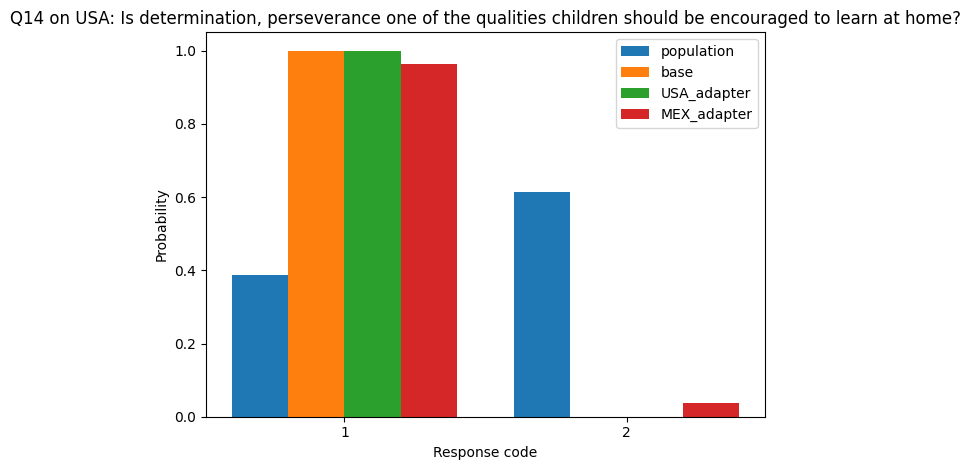

In [ ]:
# Example; change these values to inspect any question/country.
plot_question_distribution(question_specs[2]["question_id"], DATA_COUNTRY_CODES[0])

In [ ]:
#plot_question_distribution_lines("Q14", "MEX", show_option_labels=True)

In [ ]:
#plot_question_distribution_lines("Q62", "USA", show_option_labels=True)

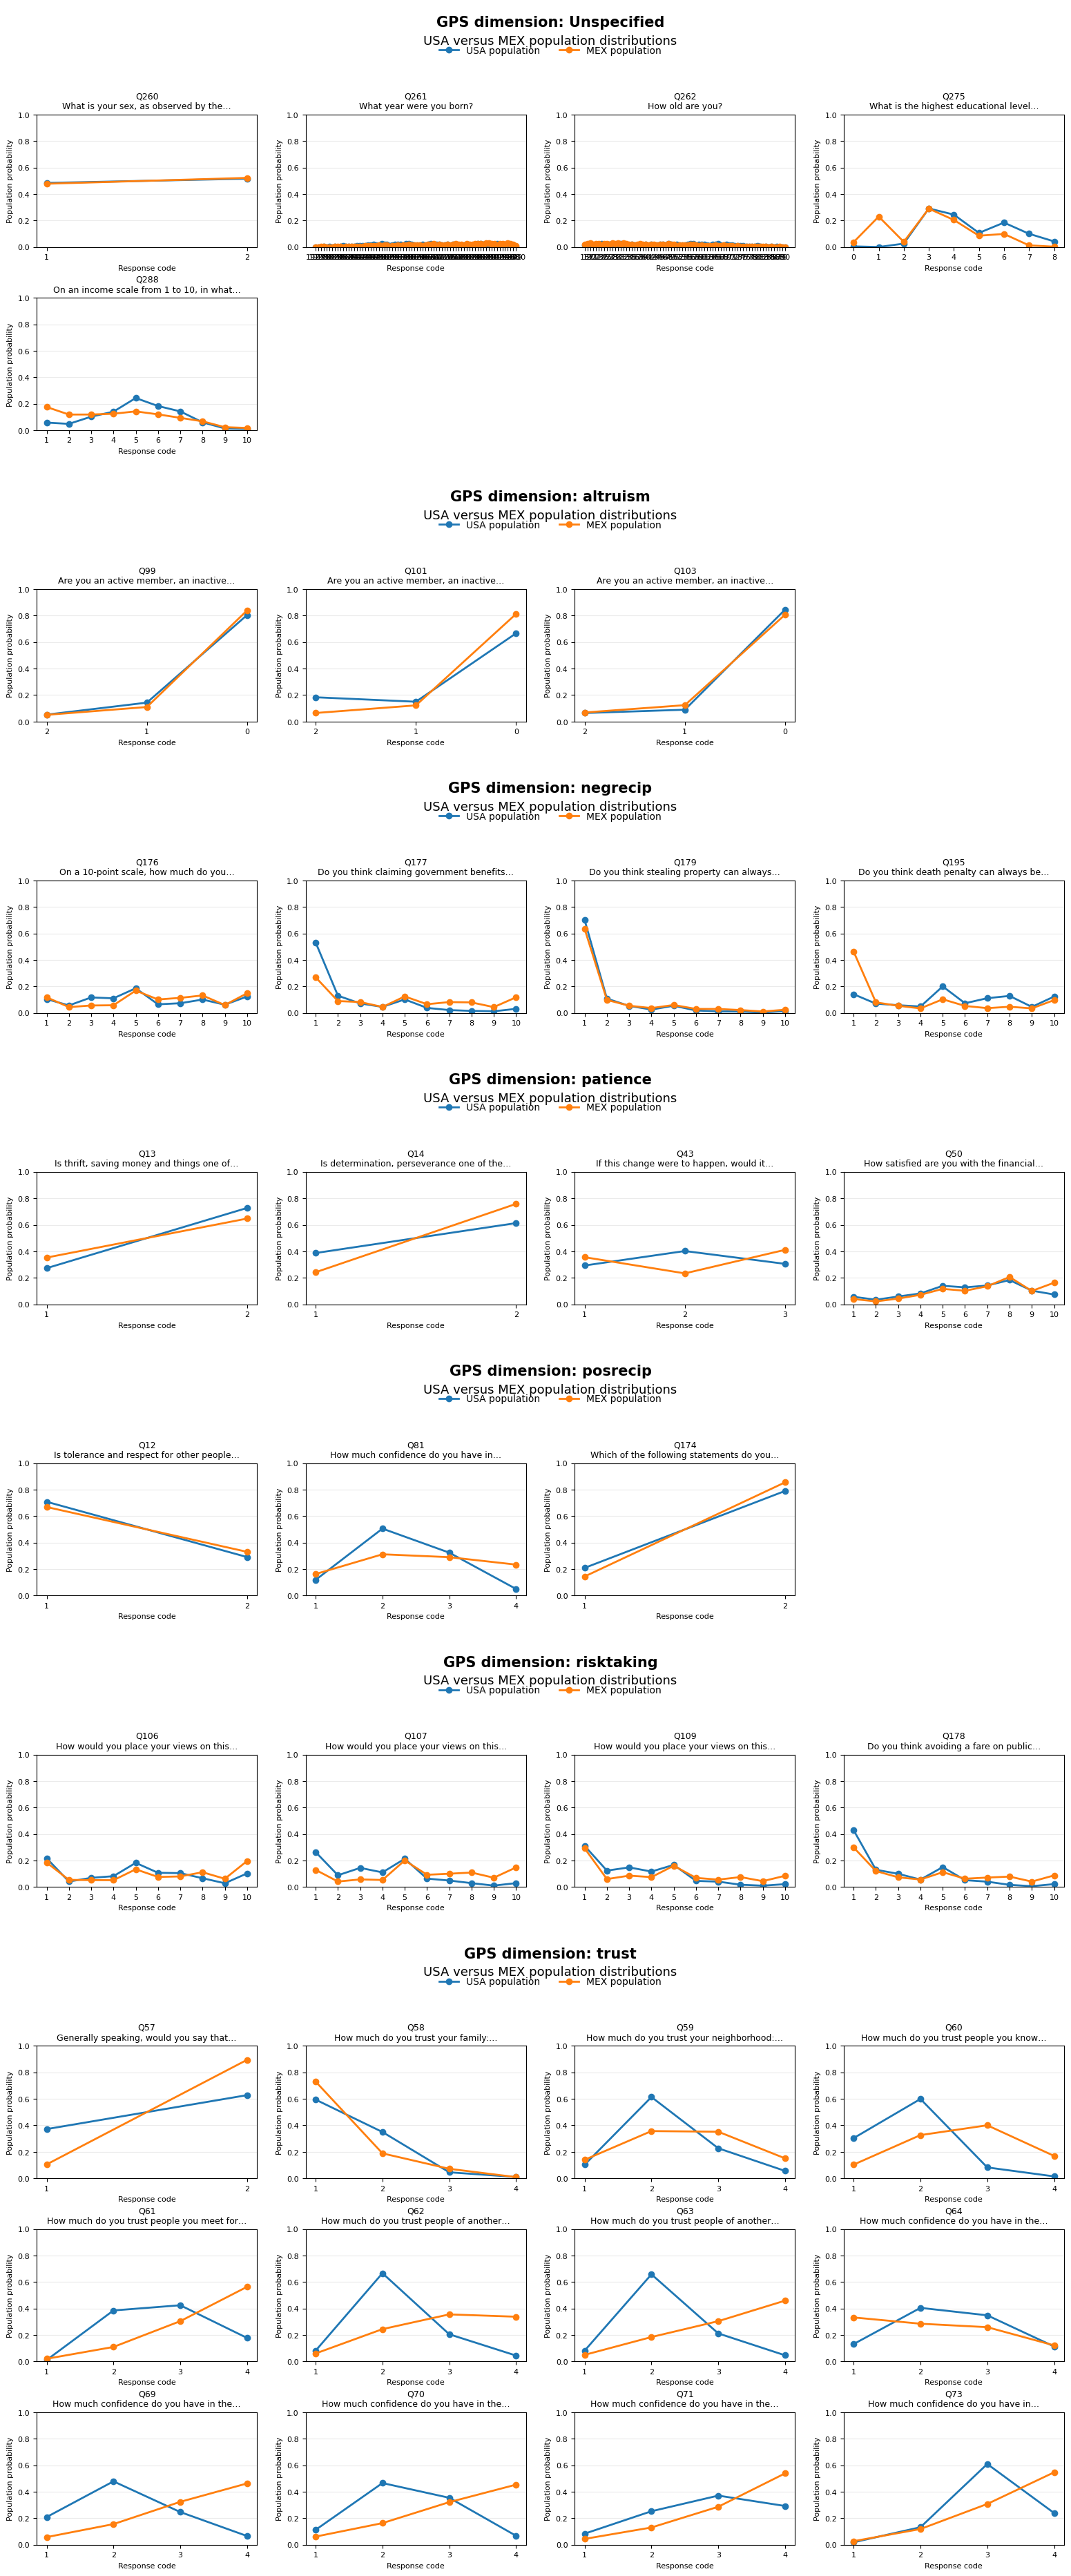

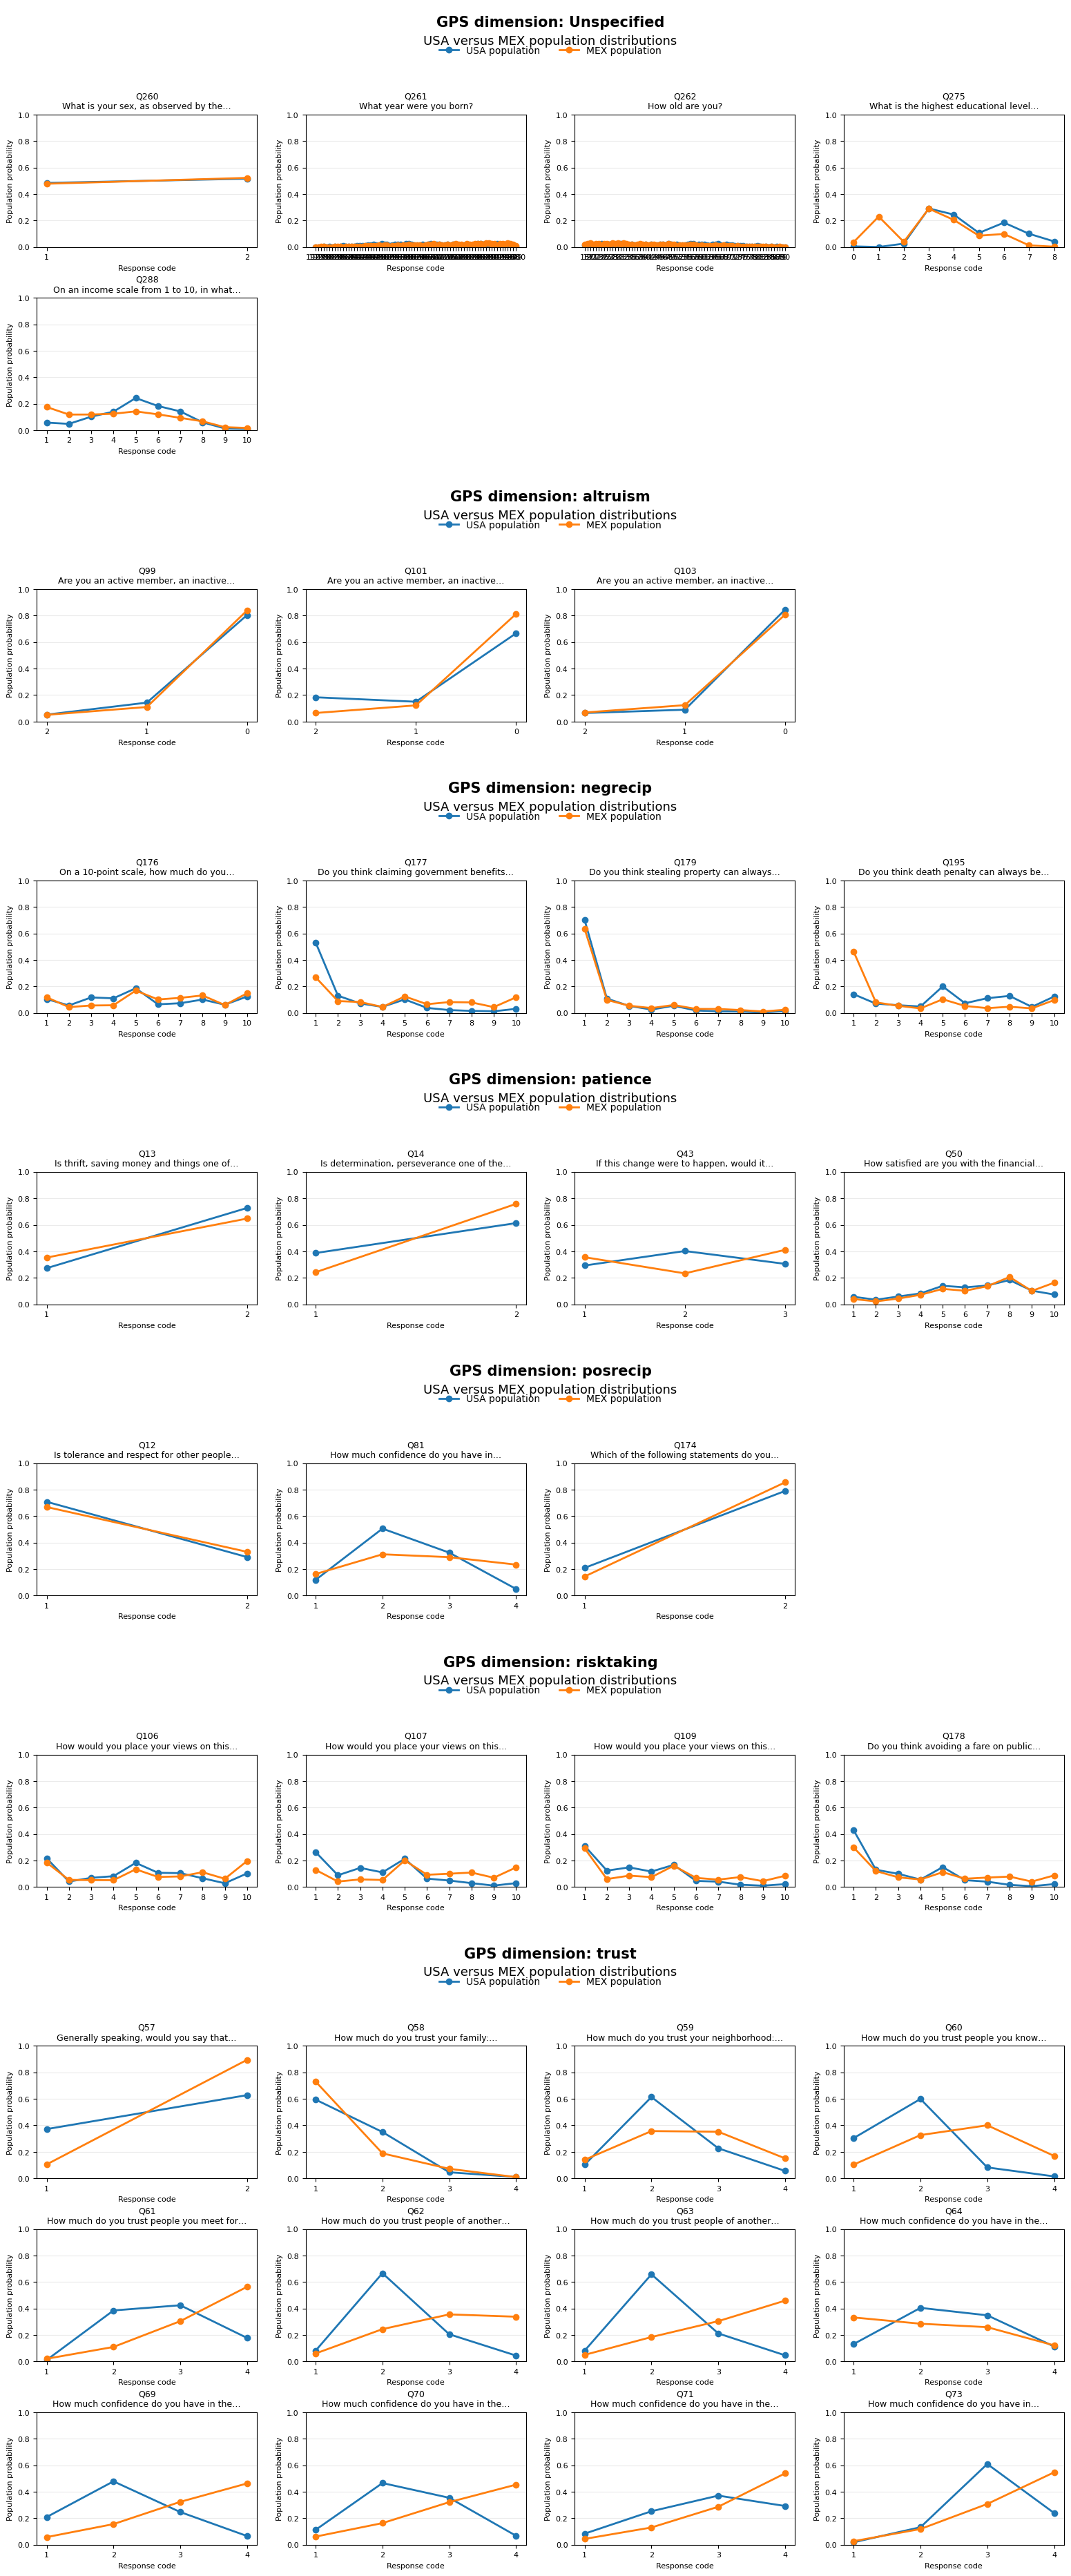

In [ ]:
plot_population_comparison_by_dimension(
    country_a="USA",
    country_b="MEX",
    n_columns=4,
    header_height=1.3,
)

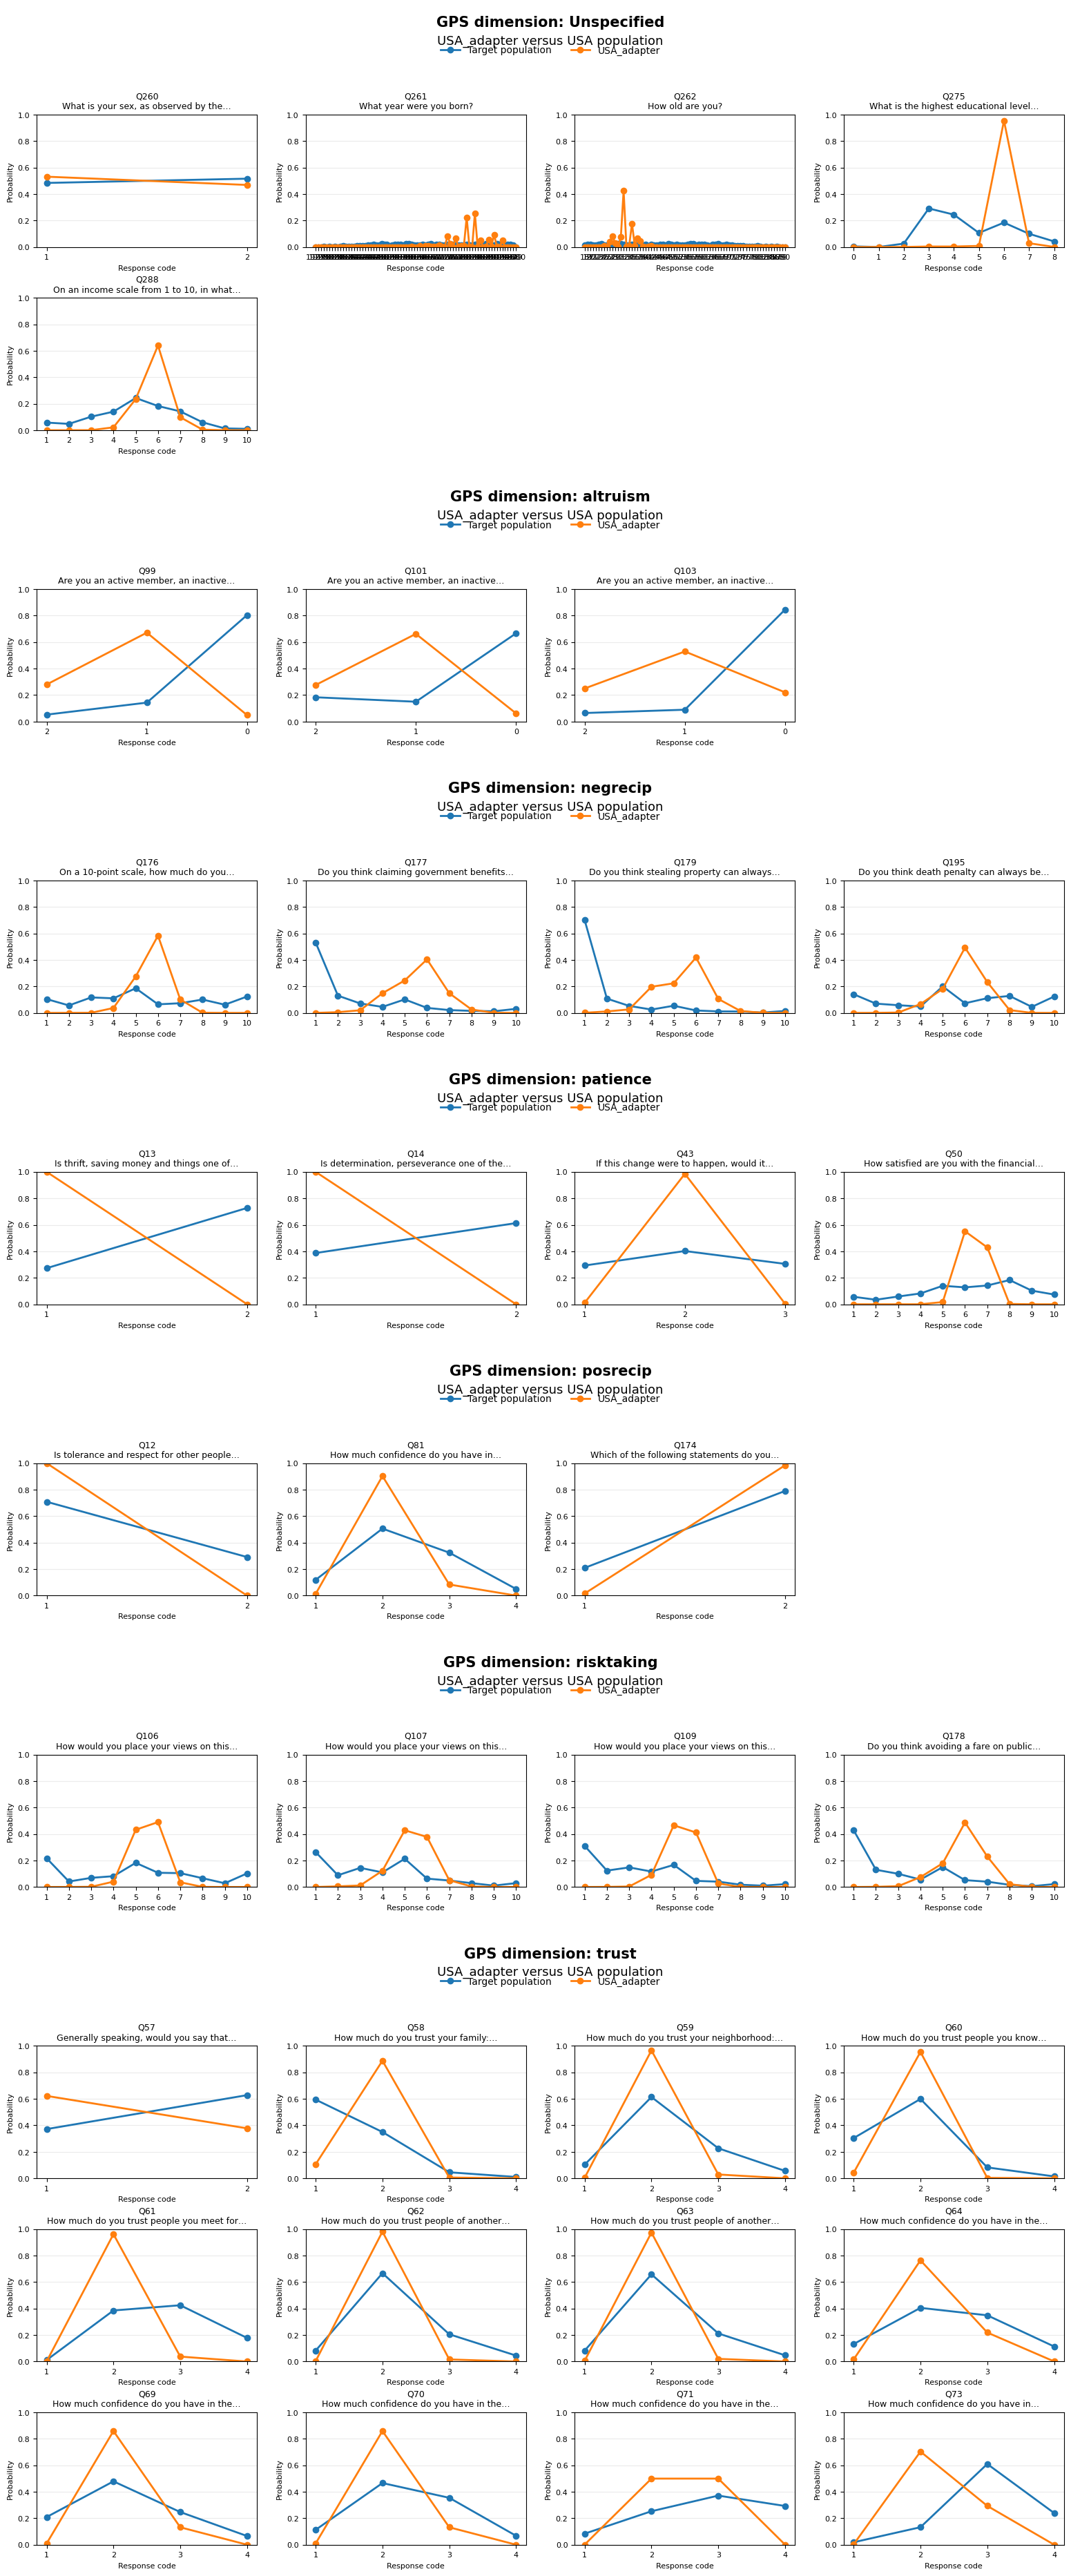

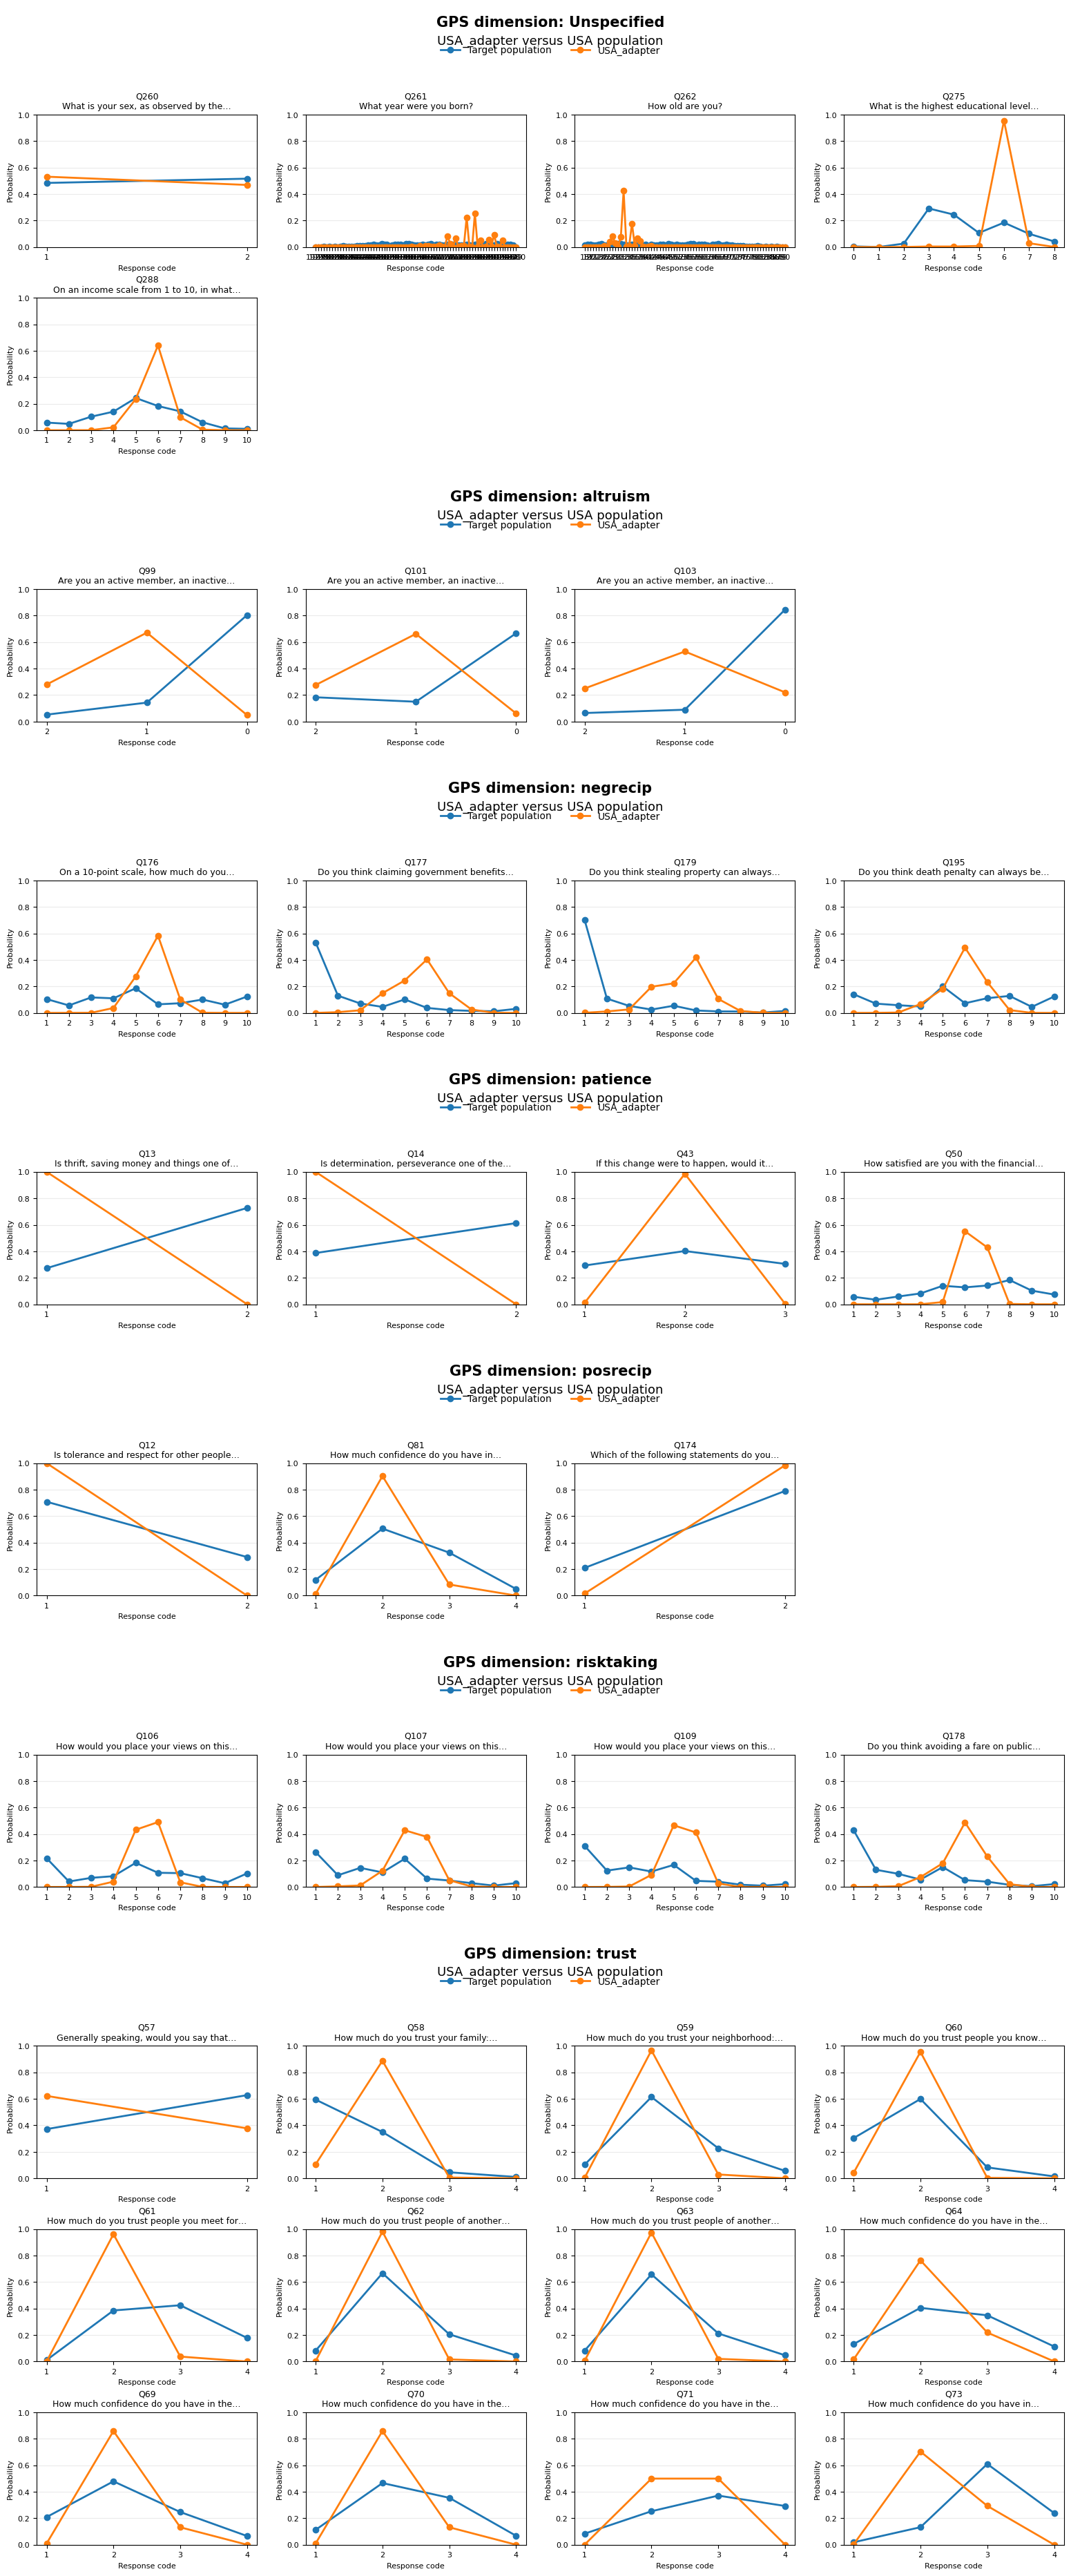

In [ ]:
plot_all_question_distributions_for_adapter("USA_adapter", header_height=1.3,)

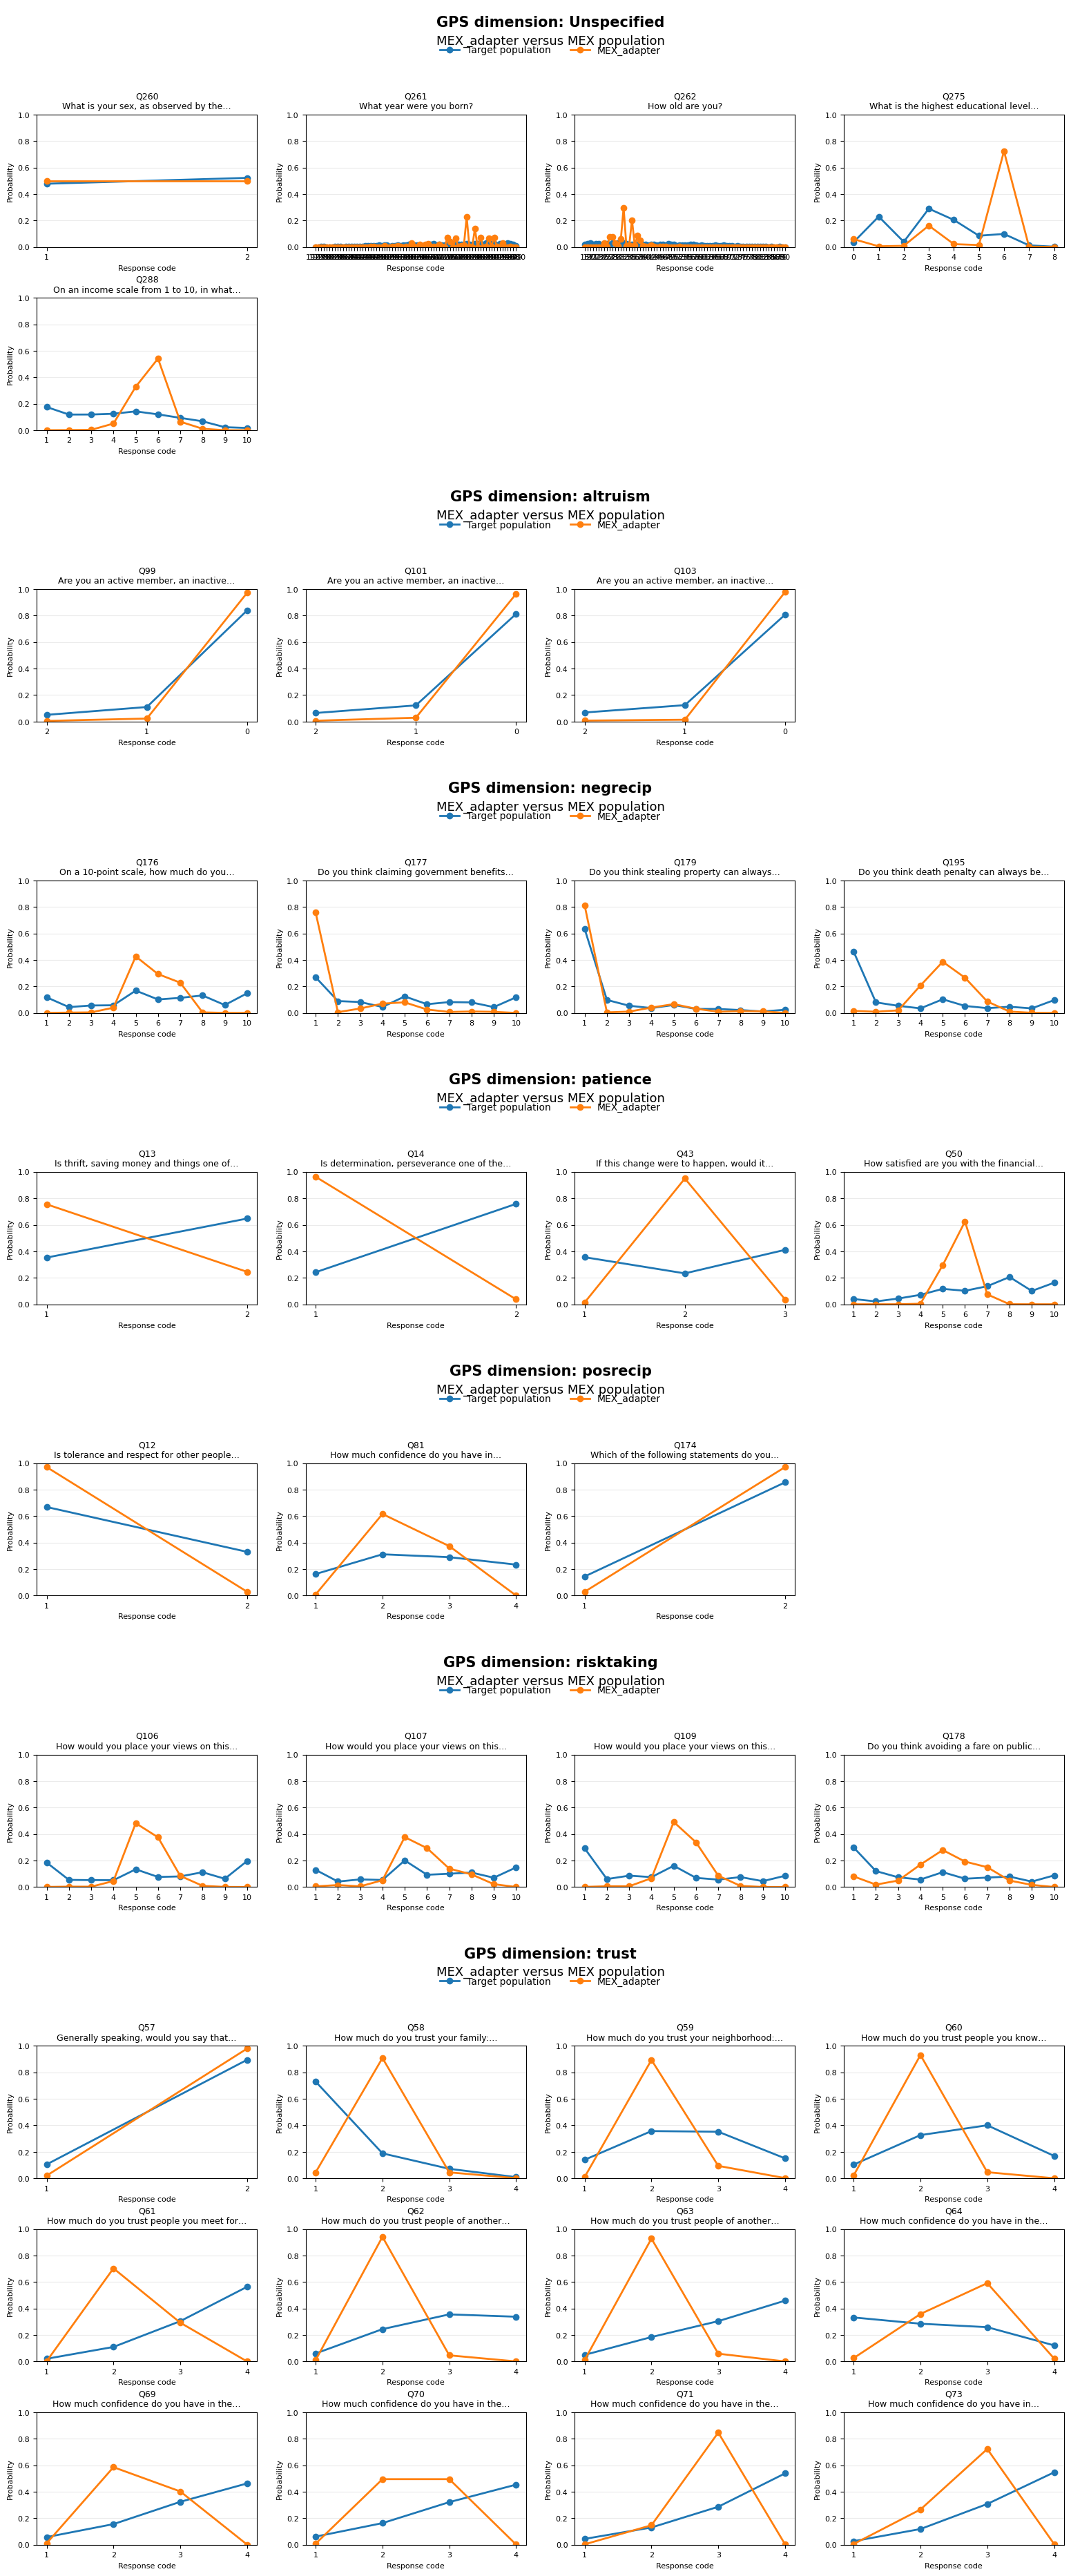

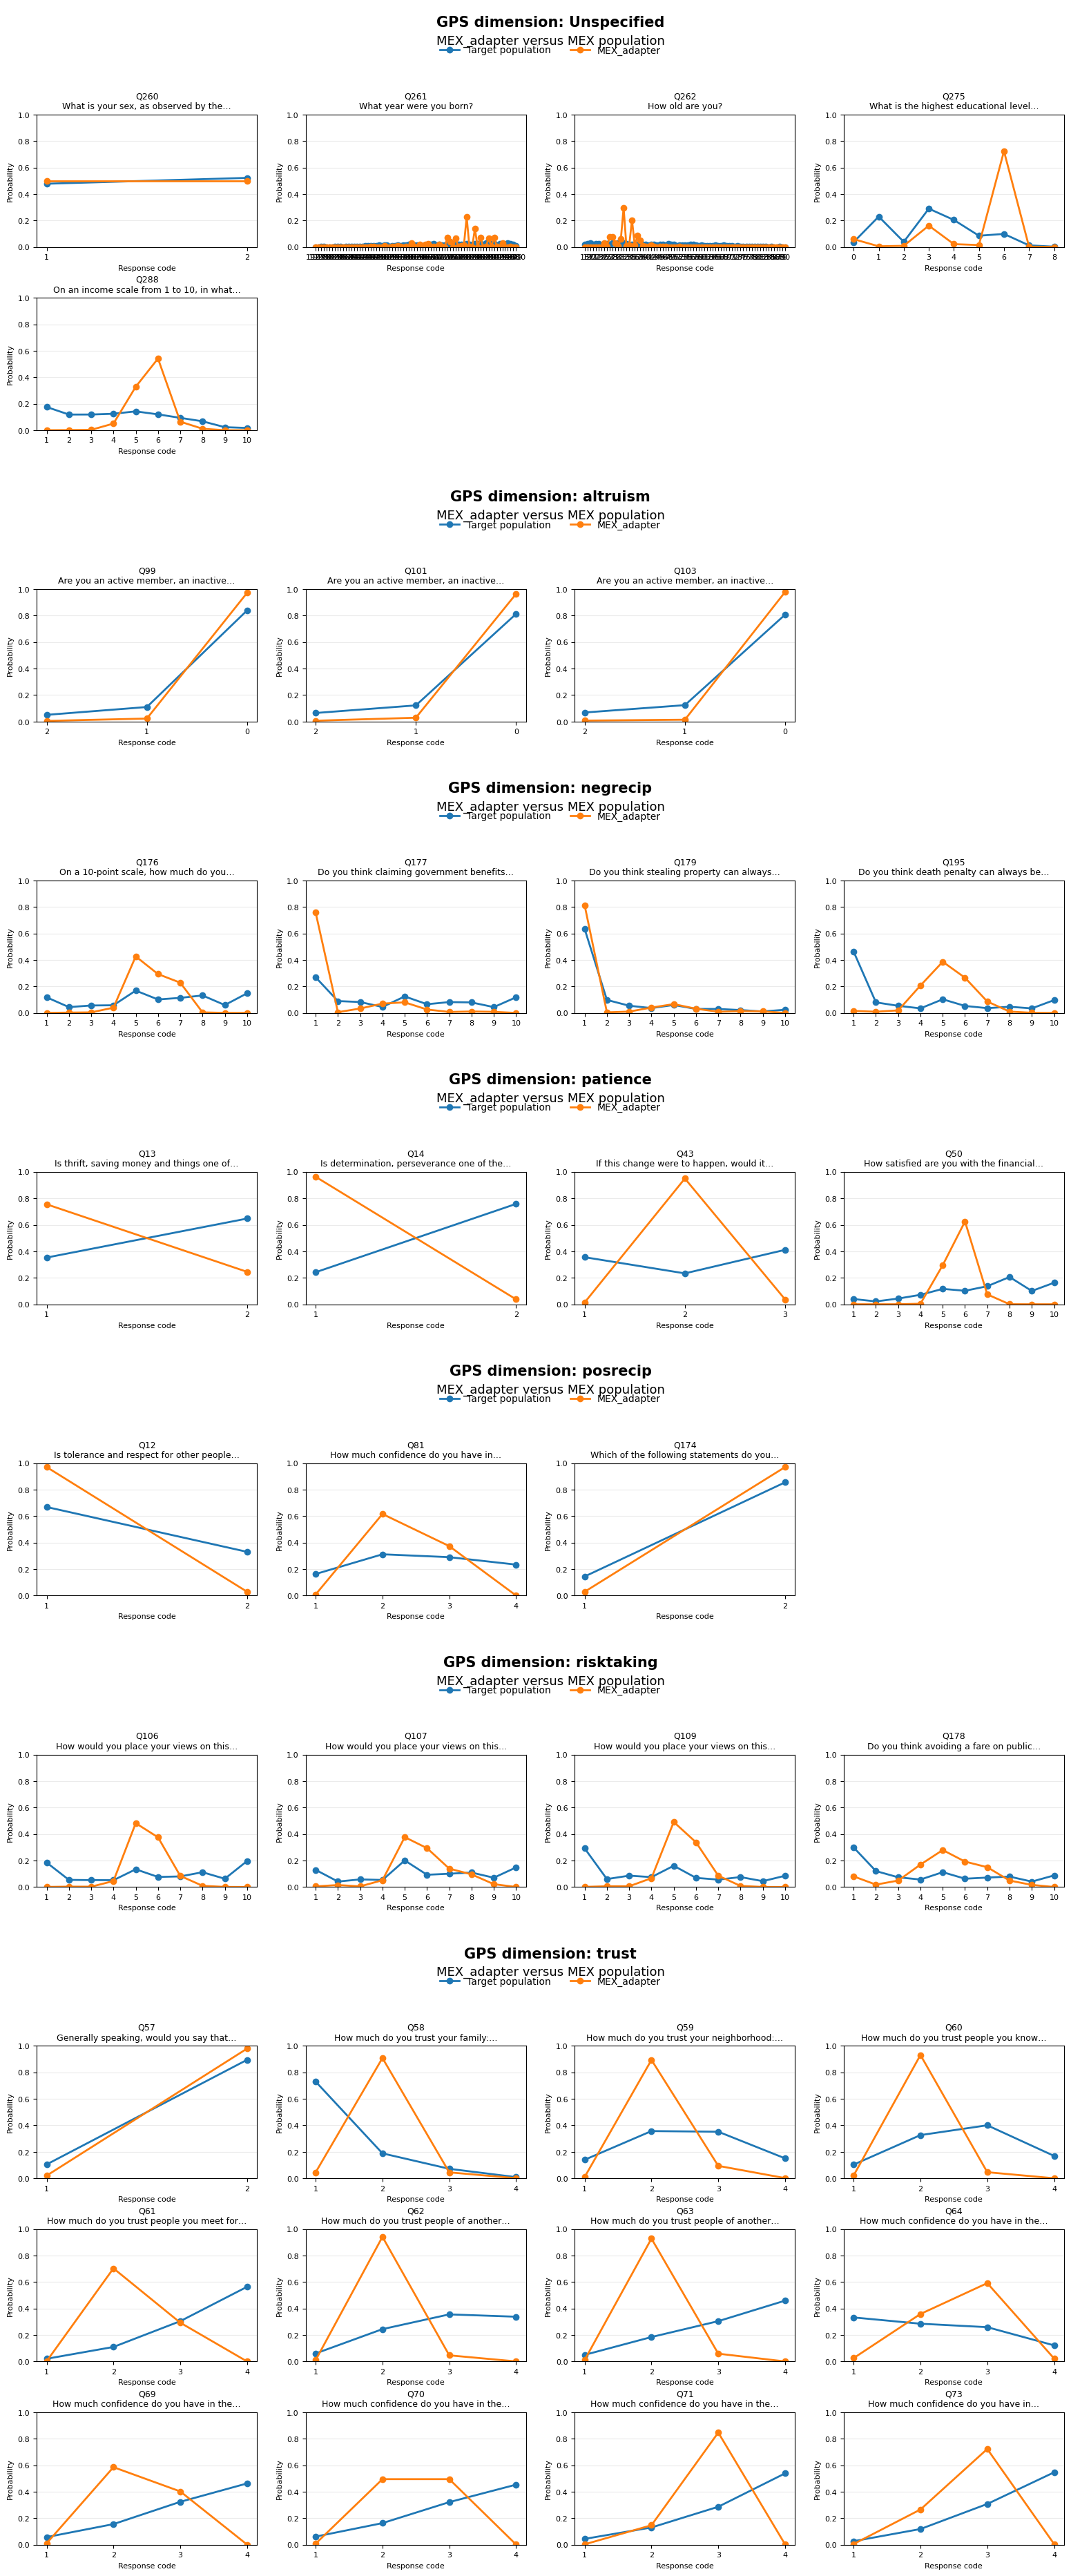

In [ ]:
plot_all_question_distributions_for_adapter("MEX_adapter",  header_height=1.3,)

In [ ]:
gps_base_improvement_summary

,model,eval_country,relationship,gps_dimension,metric,mean_improvement_over_base,median_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
0,USA_adapter,USA,matched,posrecip,tv_distance,-0.034977,-0.000060,-0.114487,0.009616,0.333333,3
1,USA_adapter,USA,matched,posrecip,js_divergence,-0.014432,-0.000250,-0.054756,0.011710,0.333333,3
2,USA_adapter,USA,matched,posrecip,brier_score,-0.034061,-0.000070,-0.109746,0.007632,0.333333,3
3,USA_adapter,USA,matched,posrecip,cross_entropy,-0.225887,-0.391184,-0.473165,0.186690,0.333333,3
4,USA_adapter,USA,matched,posrecip,wasserstein_distance,-0.057774,-0.057774,-0.115489,-0.000060,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...
191,MEX_adapter,MEX,matched,Unspecified,brier_score,0.061865,-0.005807,-0.019338,0.209498,0.400000,5
192,MEX_adapter,MEX,matched,Unspecified,cross_entropy,0.319367,0.002258,-0.291667,1.237747,0.600000,5
193,MEX_adapter,MEX,matched,Unspecified,wasserstein_distance,0.119406,-0.067452,-0.219862,0.645531,0.250000,4
194,MEX_adapter,MEX,matched,Unspecified,abs_mean_error,0.348006,0.627915,-0.386808,0.971430,0.750000,4


In [ ]:
metric_choice='wasserstein_distance'
gps_base_improvement_summary[gps_base_improvement_summary['metric']==metric_choice].groupby(['model',
                                                                                             'eval_country',
                                                                                             'gps_dimension'])['mean_improvement_over_base'].mean()

model        eval_country  gps_dimension
MEX_adapter  MEX           Unspecified      0.119406
                           altruism         0.598541
                           negrecip         0.130624
                           patience         0.030212
                           posrecip         0.100516
                           risktaking       0.020696
                           trust            0.020272
             USA           Unspecified      0.195880
                           altruism         0.425833
                           negrecip         0.029410
                           patience         0.033897
                           posrecip         0.100516
                           risktaking       0.098682
                           trust           -0.052831
USA_adapter  MEX           Unspecified     -0.981253
                           altruism        -0.111477
                           negrecip        -0.605836
                           patience        -0.027572
                           posrecip        -0.057774
                           risktaking      -0.319196
                           trust           -0.163397
             USA           Unspecified     -0.867678
                           altruism        -0.111477
                           negrecip        -1.564658
                           patience        -0.027572
                           posrecip        -0.057774
                           risktaking      -0.140217
                           trust           -0.150851
Name: mean_improvement_over_base, dtype: float64